In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading xLSTM 7B...")
xlstm_config = AutoConfig.from_pretrained("NX-AI/xLSTM-7b")
xlstm_config.step_kernel = "native"
xlstm_config.chunkwise_kernel = "chunkwise--native_autograd"
xlstm_config.sequence_kernel = "native_sequence__native"

model = AutoModelForCausalLM.from_pretrained("NX-AI/xLSTM-7b", config=xlstm_config, device_map="auto")
xlstm_tokenizer = AutoTokenizer.from_pretrained("NX-AI/xLSTM-7b")
xlstm_tokenizer.pad_token = xlstm_tokenizer.eos_token

Loading xLSTM 7B...


Loading weights: 100%|██████████| 483/483 [00:36<00:00, 13.13it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


In [3]:
# Your prompt
prompt = "The quick brown fox jumps over the lazy dog."

# Tokenize and send to the same device as the model
input_ids = xlstm_tokenizer(prompt, return_tensors="pt")['input_ids'].to(model.device)

In [18]:
import torch
import torch.nn.functional as F
from transformers.models.xlstm.modeling_xlstm import soft_cap

# ----- 1. Hook: save the input x_t to each mLSTM layer ---------------------
xs = {}   # layer index -> tensor of shape (B, T, D)

hooks = []
for ell, block in enumerate(model.backbone.blocks):
    def hook(_mod, args, kwargs, ell=ell):
        xs[ell] = (args[0] if args else kwargs["x"]).detach()
    hooks.append(block.mlstm_layer.register_forward_pre_hook(hook, with_kwargs=True))

with torch.no_grad():
    model(input_ids=input_ids)

for h in hooks: h.remove()


# ----- 2. Recompute C_t per head, per timestep -----------------------------
@torch.no_grad()
def cell_states(layer_idx):
    layer = model.backbone.blocks[layer_idx].mlstm_layer
    cfg   = layer.config
    H     = cfg.num_heads               # number of heads
    cap   = cfg.gate_soft_cap

    x = xs[layer_idx].float()           # (B, T, D)
    B, T, _ = x.shape

    # --- projections (same as the layer would do) ---
    if cfg.weight_mode == "single":
        q = layer.q(x); k = layer.k(x); v = layer.v(x)
        i_hat = soft_cap(layer.igate_preact(x), cap)   # (B, T, H)
        f_hat = soft_cap(layer.fgate_preact(x), cap)
    else:  # "fused"
        qkvo = layer.qkv_opreact(x)
        q, k, v, _ = torch.tensor_split(
            qkvo, (layer.qk_dim, 2*layer.qk_dim, 2*layer.qk_dim + layer.v_dim), dim=-1)
        ifp = soft_cap(layer.ifgate_preact(x), cap)
        i_hat, f_hat = torch.tensor_split(ifp, (H,), dim=-1)

    # split heads -> (B, H, T, d_*)
    q = q.view(B, T, H, -1).transpose(1, 2).float()
    k = k.view(B, T, H, -1).transpose(1, 2).float()
    v = v.view(B, T, H, -1).transpose(1, 2).float()
    i_hat = i_hat.transpose(1, 2).float()              # (B, H, T)
    f_hat = f_hat.transpose(1, 2).float()
    d_k, d_v = q.shape[-1], v.shape[-1]

    # --- initial states (per the paper, all zero) ---
    C = torch.zeros(B, H, d_k, d_v, device=x.device)
    n = torch.zeros(B, H, d_k,       device=x.device)
    m = torch.zeros(B, H, 1,         device=x.device)

    C_seq = []          # will hold C_1, C_2, ..., C_T
    fbar_seq, ibar_seq = [], []   # gate activations per step

    for t in range(T):
        i_t = i_hat[:, :, t:t+1]                       # (B, H, 1)
        f_t = f_hat[:, :, t:t+1]
        k_t = k[:, :, t]                               # (B, H, d_k)
        v_t = v[:, :, t]                               # (B, H, d_v)

        # --- paper equations ---
        f_log  = F.logsigmoid(f_t)
        m_new  = torch.maximum(f_log + m, i_t)
        f_bar  = torch.exp(f_log + m - m_new)          # forget activation
        i_bar  = torch.exp(i_t - m_new)                # input activation

        kv     = k_t.unsqueeze(-1) * v_t.unsqueeze(-2) # outer product k_t v_t^T
        C      = f_bar.unsqueeze(-1) * C + i_bar.unsqueeze(-1) * kv
        n      = f_bar * n + i_bar * k_t
        m      = m_new

        C_seq.append(C.clone())
        fbar_seq.append(f_bar.squeeze(-1).clone())     # (B, H)
        ibar_seq.append(i_bar.squeeze(-1).clone())

    C_seq    = torch.stack(C_seq)        # (T, B, H, d_k, d_v)
    fbar_seq = torch.stack(fbar_seq)     # (T, B, H)
    ibar_seq = torch.stack(ibar_seq)
    return C_seq, fbar_seq, ibar_seq


C, fbar, ibar = cell_states(layer_idx=31)
print(C.shape)        # (T, B, num_heads, d_k, d_v)```

torch.Size([10, 1, 8, 256, 512])


max abs err : 1.494e+01
mean abs err: 2.896e-01
max rel err : 7.838e+05
allclose    : False


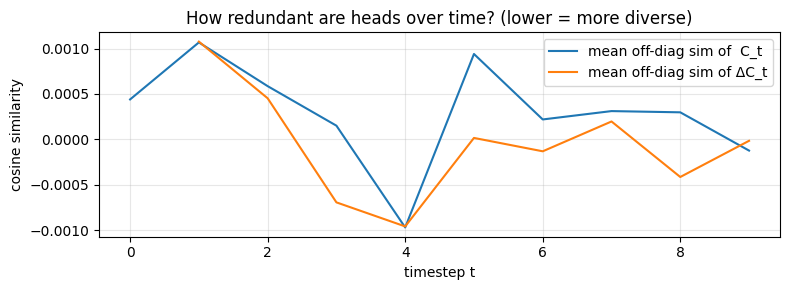

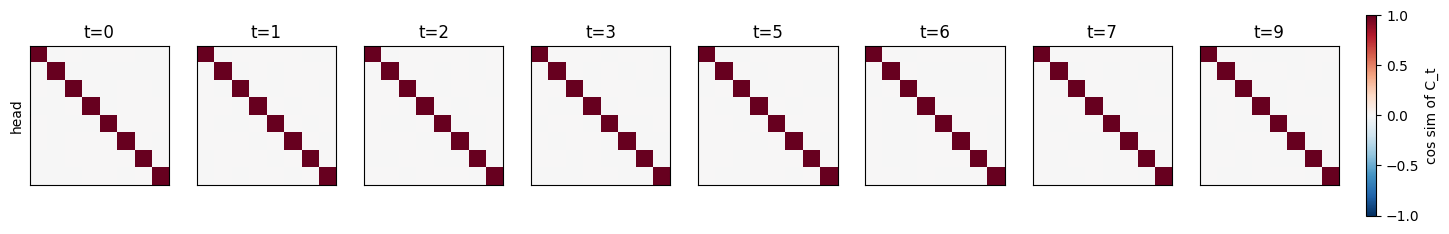

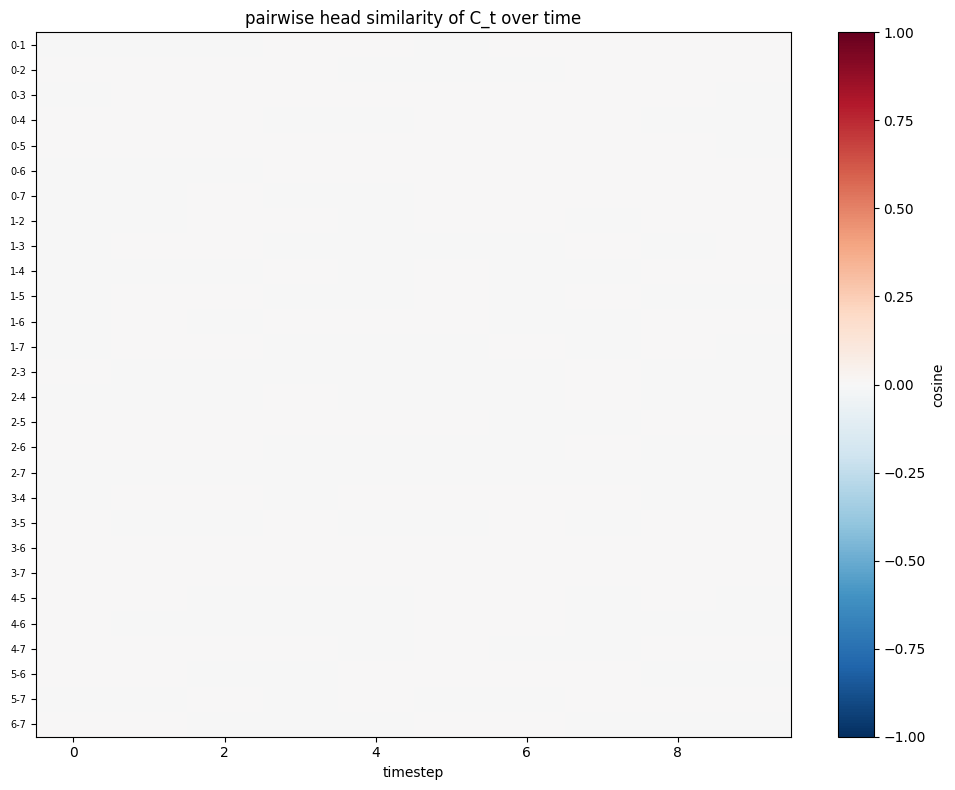

In [19]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ---------- 1. Sanity check: hand-rolled C_T must match the model's cache ----
# (Run a forward pass with use_cache=True so the model stores the final state.)
with torch.no_grad():
    out = model(input_ids=input_ids, use_cache=True)

C_model = out.cache_params.rnn_state[0][0]      # (B, H, d_k, d_v) -- layer 0
C_mine  = C[-1].to(C_model.dtype).to(C_model.device)   # last step from your script

abs_err = (C_mine - C_model).abs()
rel_err = abs_err / (C_model.abs() + 1e-6)

print(f"max abs err : {abs_err.max().item():.3e}")
print(f"mean abs err: {abs_err.mean().item():.3e}")
print(f"max rel err : {rel_err.max().item():.3e}")
print("allclose    :", torch.allclose(C_mine, C_model, atol=1e-3, rtol=1e-3))


# ---------- 2. Pairwise head cosine similarity at every timestep ------------
# C has shape (T, B, H, d_k, d_v). Pick a batch item and flatten per head.
b = 0
T, _, H = C.shape[:3]
flat = C[:, b].reshape(T, H, -1)                # (T, H, d_k*d_v)
flat = F.normalize(flat, dim=-1)
sim  = torch.einsum("thd,tgd->thg", flat, flat) # (T, H, H)

# (optional) similarity of the *update* dC_t instead of C_t — often more informative
dC      = C[1:, b] - C[:-1, b]                  # (T-1, H, d_k, d_v)
dflat   = F.normalize(dC.reshape(T-1, H, -1), dim=-1)
sim_dC  = torch.einsum("thd,tgd->thg", dflat, dflat)


# ---------- 3. Plots --------------------------------------------------------
sim_np    = sim.cpu().numpy()
sim_dC_np = sim_dC.cpu().numpy()

# (a) Mean off-diagonal similarity over time: one number per timestep ---------
mask  = ~torch.eye(H, dtype=torch.bool)
mean_off = sim[:, mask].mean(-1).cpu().numpy()           # (T,)
mean_off_dC = sim_dC[:, mask].mean(-1).cpu().numpy()     # (T-1,)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(mean_off,    label="mean off-diag sim of  C_t")
ax.plot(range(1, T), mean_off_dC, label="mean off-diag sim of ΔC_t")
ax.set_xlabel("timestep t")
ax.set_ylabel("cosine similarity")
ax.set_title("How redundant are heads over time? (lower = more diverse)")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

# (b) Per-timestep H×H similarity heatmaps as a small-multiples grid ----------
# show a handful of timesteps spread across the sequence
n_panels = min(8, T)
ts = torch.linspace(0, T-1, n_panels).long().tolist()
fig, axes = plt.subplots(1, n_panels, figsize=(2.2*n_panels, 2.6), sharey=True)
for ax, t in zip(axes, ts):
    im = ax.imshow(sim_np[t], vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_title(f"t={t}"); ax.set_xticks([]); ax.set_yticks([])
axes[0].set_ylabel("head")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="cos sim of C_t")
plt.show()

# (c) "Time vs. head-pair" heatmap: every head pair, every timestep -----------
# rows = the H*(H-1)/2 unique pairs, cols = time
iu, ju = torch.triu_indices(H, H, offset=1)
pairs_over_time = sim[:, iu, ju].cpu().numpy().T     # (n_pairs, T)

fig, ax = plt.subplots(figsize=(10, 0.25*pairs_over_time.shape[0] + 1))
im = ax.imshow(pairs_over_time, aspect="auto", vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_yticks(range(len(iu)))
ax.set_yticklabels([f"{i.item()}-{j.item()}" for i, j in zip(iu, ju)], fontsize=7)
ax.set_xlabel("timestep")
ax.set_title("pairwise head similarity of C_t over time")
fig.colorbar(im, ax=ax, label="cosine"); plt.tight_layout(); plt.show()

# (d) Mean cell states over time: H x T heatmap -------------------------------
mean_C_over_time = C[:, b].mean(dim=(-1, -2)).cpu().numpy().T  # (H, T)

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(mean_C_over_time, aspect="auto", cmap="viridis")
ax.set_yticks(range(H))
ax.set_ylabel("head")
ax.set_xlabel("timestep")
ax.set_title("Mean cell state of C_t over time")
fig.colorbar(im, ax=ax, label="mean value"); plt.tight_layout(); plt.show()

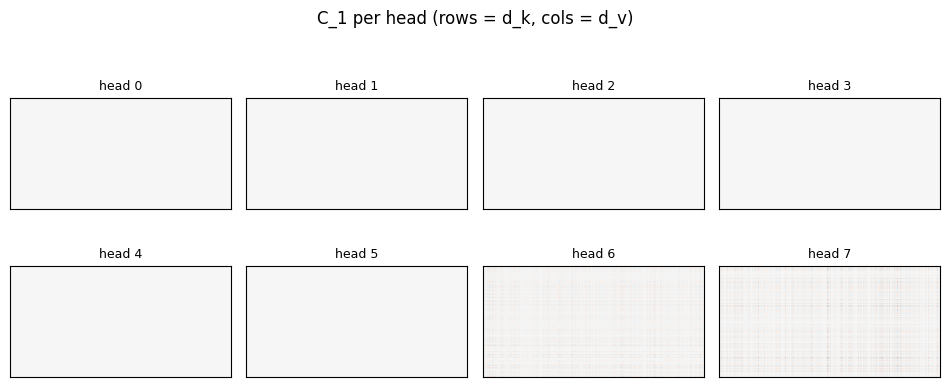

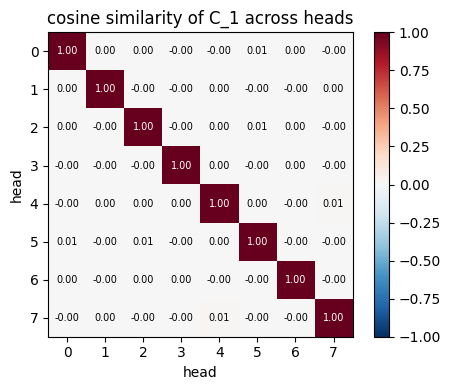

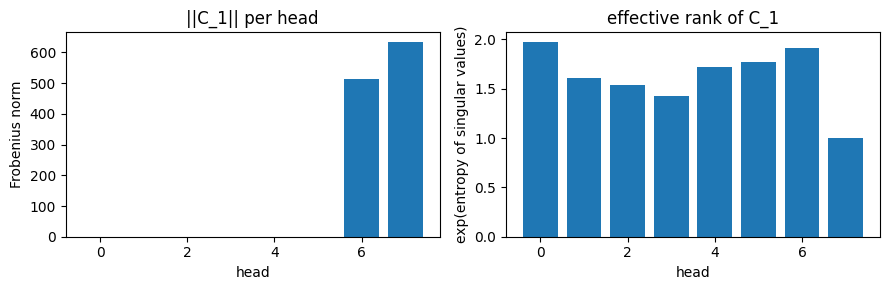

In [15]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

b = 0          # batch item
t = 1          # the timestep you want to inspect (e.g. C_1)
Ct = C[t, b]   # (H, d_k, d_v)
H  = Ct.shape[0]

# ---------- View 1: visualize each head's C_t as a heatmap -----------------
vmax = Ct.abs().max().item()
ncols = 4
nrows = (H + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(2.4*ncols, 2.2*nrows))
for h, ax in enumerate(axes.flat):
    if h < H:
        ax.imshow(Ct[h].cpu(), vmin=-vmax, vmax=vmax, cmap="RdBu_r")
        ax.set_title(f"head {h}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"C_{t} per head (rows = d_k, cols = d_v)")
plt.tight_layout(); plt.show()


# ---------- View 2: pairwise cosine similarity between heads at time t -----
flat = F.normalize(Ct.reshape(H, -1), dim=-1)        # (H, d_k*d_v)
S    = flat @ flat.T                                 # (H, H)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(S.cpu(), vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(H)); ax.set_yticks(range(H))
ax.set_xlabel("head"); ax.set_ylabel("head")
ax.set_title(f"cosine similarity of C_{t} across heads")
for i in range(H):                                   # annotate cells
    for j in range(H):
        ax.text(j, i, f"{S[i,j]:.2f}", ha="center", va="center",
                fontsize=7, color="black" if abs(S[i,j])<0.5 else "white")
fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()


# ---------- View 3: scalar summary per head at time t ----------------------
norms      = Ct.flatten(1).norm(dim=-1)              # how big is each head's memory
# effective rank via singular value entropy
sv         = torch.linalg.svdvals(Ct.float())        # (H, min(d_k,d_v))
p          = sv / sv.sum(-1, keepdim=True)
eff_rank   = torch.exp(-(p * (p + 1e-12).log()).sum(-1))   # (H,)

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].bar(range(H), norms.cpu()); axes[0].set_title(f"||C_{t}|| per head")
axes[0].set_xlabel("head"); axes[0].set_ylabel("Frobenius norm")
axes[1].bar(range(H), eff_rank.cpu()); axes[1].set_title(f"effective rank of C_{t}")
axes[1].set_xlabel("head"); axes[1].set_ylabel("exp(entropy of singular values)")
plt.tight_layout(); plt.show()

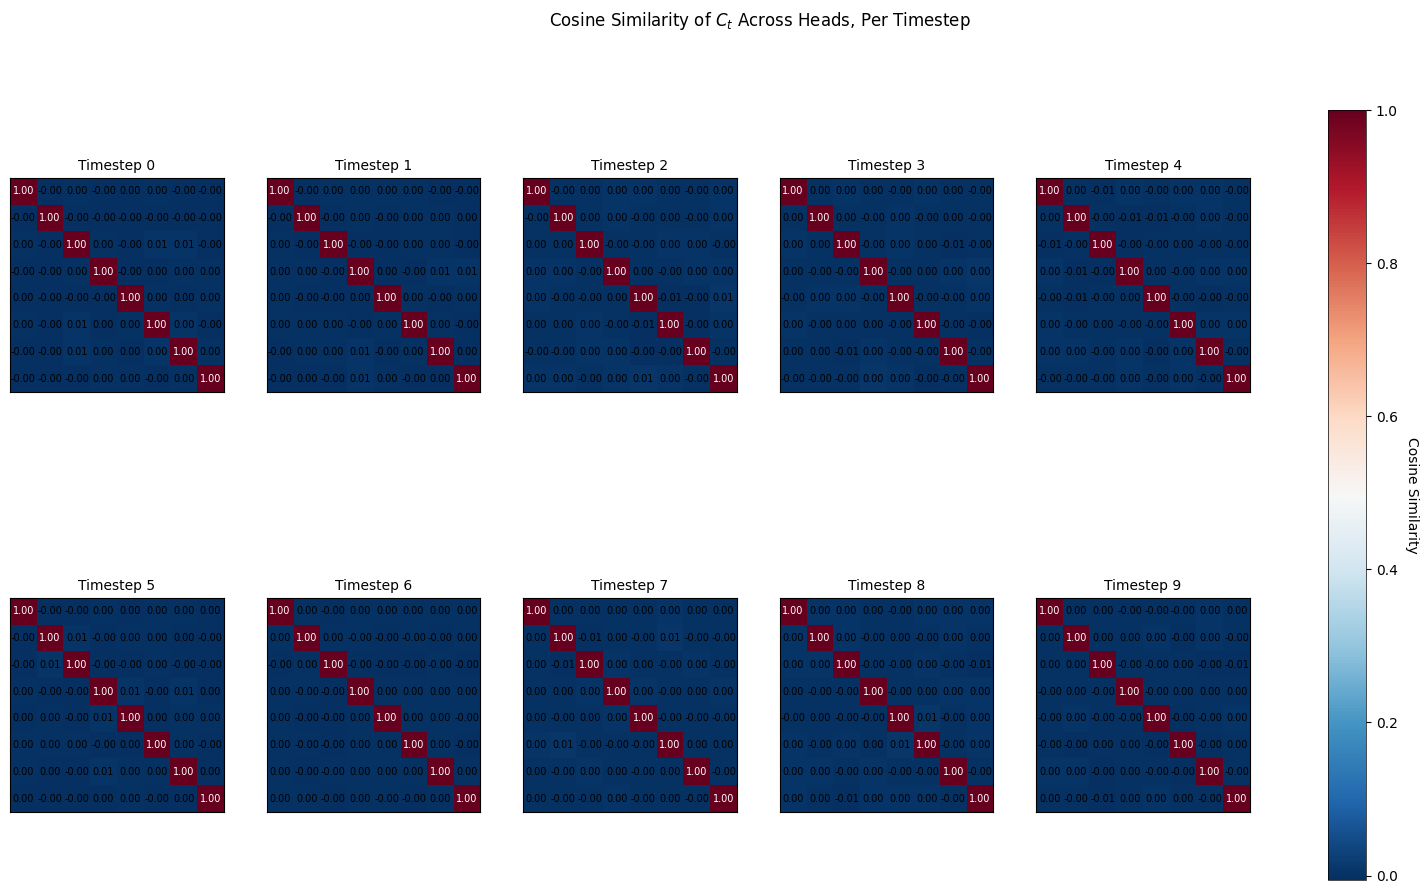

In [20]:
import math
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

b = 0                                   # batch item
T, _, H = C.shape[:3]

# Pairwise cosine similarity at every timestep -> (T, H, H)
flat = F.normalize(C[:, b].reshape(T, H, -1), dim=-1)
sim  = torch.einsum("thd,tgd->thg", flat, flat).cpu()

# ---- Grid of small heatmaps, organized in exactly 2 rows 
nrows = 2
ncols = math.ceil(T / nrows)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 10))

annotate = H <= 8                       # only annotate cells when readable

for t in range(nrows * ncols):
    row, col = divmod(t, ncols)
    ax = axes[row, col]
    
    if t < T:
        im = ax.imshow(sim[t] , cmap="RdBu_r")
        ax.set_title(f"Timestep {t}", fontsize=10, pad=6, fontweight='medium')
        
        if annotate:
            for i in range(H):
                for j in range(H):
                    val = sim[t, i, j].item()
                    text_color = "black" if abs(val) < 0.6 else "white"
                    ax.text(j, i, f"{val:.2f}",
                            ha="center", va="center", fontsize=7,
                            color=text_color)
                            
        # Clean up the axes by hiding ticks
        ax.set_xticks([])
        ax.set_yticks([])
        

# Add a professional-looking main title
fig.suptitle("Cosine Similarity of $C_t$ Across Heads, Per Timestep")

# Create a single neat colorbar on the right for the entire grid
cbar = fig.colorbar(im, ax=axes.ravel().tolist())
cbar.set_label("Cosine Similarity", rotation=270, labelpad=15)
cbar.outline.set_linewidth(0.5)

plt.show()
